In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
import scipy

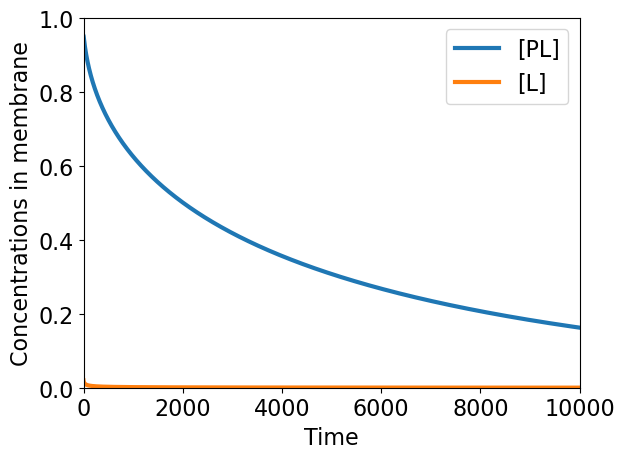

In [4]:
#parameters
ka = 10    #membrane to protein binding rate (1/(M*s))
kd = 0.01  #protein to membrane dissociation rate (1/s), aka k_{-a}
pt = 1     #total protein (M), aka [P_{t}]
k1 = 0.1   #membrane to water partitioning rate (1/s), aka k_{lw}

#full differential equations describing a washout experiment
def pl_flux(pl, lm):
    #this returns d[PL]/dt
    return ka*(pt - pl)*lm - kd*pl

def lm_flux(pl, lm):
    #this returns d[LM]/dt
    return -k1*lm - pl_flux(pl,lm)

#differential equation for steady state
def pl_flux_ss(pl):
    #this returns d[LM]/dt for the steady state
    return -pl*kd*k1/(k1+ka*(pt-pl))

#integrator settings
dt = 0.01
tmax = 1000000

#initial ligand concentration in the membrane
lm = 0.02 #kd/(ka*pt)#10

#set initial protein-ligand complex concentration so that 
#  the system is in equilibrium prior to the start of ligand washout
pl = pt*lm/(lm+kd/ka)
pl_ss = pl

#data collection
    #timesteps
t_trj = [0]
    #full differential equations
pl_trj = [pl]
lm_trj = [lm]
    #steady state differential equation
pl_ss_trj = [pl_ss]

#integrate with euler integrator
for t in range(tmax):
    t_trj.append((t+1)*dt)

    #full diffeqs
    pl += pl_flux(pl,lm)*dt
    lm += lm_flux(pl,lm)*dt
    pl_trj.append(pl)
    lm_trj.append(lm)

    #steady state
    pl_ss += pl_flux_ss(pl_ss)*dt
    pl_ss_trj.append(pl_ss)

#plot trajectories
plt.plot(t_trj, pl_trj, linewidth=3)
plt.plot(t_trj, lm_trj, linewidth=3)
#plt.plot(t_trj, pl_ss_trj)

pad = 0.01
# plt.xlim(-tmax*dt*pad,tmax*dt)
# plt.ylim(0,pt*(1+pad))
plt.xlim(0,tmax*dt)
plt.ylim(0,pt)
plt.xlabel("Time")
plt.ylabel("Concentrations in membrane")

plt.legend(["[PL]", "[L]"])#, "[PLss]"])
plt.rcParams.update({'font.size': 16})
plt.savefig("washout_diffeq_traces.png",dpi=600, bbox_inches="tight")

plt.show()

In [ ]:
#note that x and y here are not the same as below
#solve x = f(y, params) to obtain y at fixed x intervals dx
def solve_implicit_at_fixed_intervals(x_y, dy_dx_y, params, y0, y1, dx, tolerance=-1):
    
    if tolerance == -1:
        tolerance = dx/100 #1% step size error
    
    x_trj = []
    y_trj = []
    
    y = y0
    while y >= y1:
        y_trj.append(y)
        x_trj.append(x_y(y, *params))

        #linear estimate of y step that will yield desired x step
        dy = dy_dx_y(y, *params)*dx
        if y+dy <= 0: #this is needed because our current expression x(y) contains a logarithm
            dy = -y/2
            
        #check if x step is actually right and adjust otherwise until it converges
        dy_over = dy
        dy_under = 0

        while abs(abs(x_y(y+dy, *params)-x_trj[-1])-dx) > tolerance:
            if abs(x_y(y+dy, *params)-x_trj[-1])-dx > tolerance:
                dy_over = dy
                dy = (dy_over + dy_under)/2
            elif abs(x_y(y+dy, *params)-x_trj[-1])-dx < -tolerance:
                dy_under = dy
                dy = (dy_over + dy_under)/2  
                                
        y += dy
        
    return x_trj, y_trj

In [ ]:
#equations for fraction of bound protein over time derived from steady state
def t_x(x, kd, ka, pt, k1):
    return (-(k1 + ka*pt)*np.log(x) + ka*pt*(x-1))/(kd*k1)

def dx_dt_x(x, kd, ka, pt, k1):
    return -x*kd*k1/(k1 + ka*pt*(1-x))

In [ ]:
#parameters
ka = 100   #membrane to protein binding rate (1/(M*s))
kd = 0.01  #protein to membrane dissociation rate (1/s), aka k_{-a}
pt = 1     #total protein (M), aka [P_{t}]
#k1 = 0.01

#k_exp = m*k1*kd/(ka*pt), where m is about 1.52. 
#This is independent of the data length in the limit of t--> inf,
#but not in the limit of t-->0 

#ligand bound protein fraction range to fit exponential over and the timestep
x0 = 1
x1 = 0.001
dt = 100

#scan across k1 values and record the resulting tau
k1s = []
taus = []
lasttau = 10000000 #used to help the exponential fit converge faster

check_timesteps = False #for debugging

for lnk1 in np.arange(-3, 1, 1):
    
    k1 = 10.0**lnk1 #this is an efficient way of scanning across several orders of magnitude of k1
    
    params = (kd, ka, pt, k1)
    k1s.append(k1)    
    print(k1)
    
    t, x = solve_implicit_at_fixed_intervals(t_x, dx_dt_x, params, x0, x1, dt, tolerance=-1)
    plt.plot(t,x)
    #plt.show()

    if check_timesteps:
        #verify uniform timesteps
        delta_t = [t[i+1]-t[i] for i in range(len(t)-1)]
        plt.plot(t[0:-1], delta_t)
        plt.show()

    #direct exponential least squares fit
    #this is not the same as a fit to linearized data, which is biased and will yield worse approximations
    cf = scipy.optimize.curve_fit(lambda t,a,T: a*np.exp(-t/T), t, x, p0=(1, lasttau))
    taus.append(cf[0][1])
    lasttau = cf[0][1]

    #plot exponential fit
    xexp = [cf[0][0]*np.exp(-ti/cf[0][1]) for ti in t]

    plt.plot(t, xexp)
    #plt.show()

plt.xlabel("time")
plt.ylabel("fraction of bound protein")
plt.show()

#best fit tau values
taurates = [1/T for T in taus]
plt.scatter(k1s, taurates)

#approximate slope of the tau-vs-k1 line
#this has a variable intercept which does not match the functional form of eq. 33.
# slope, intercept, r_value, p_value, std_err = scipy.stats.linregress(k1s, taus)
# fit_line = slope*np.array(k1s) + intercept*np.ones(len(k1s))
# plt.plot(k1s, fit_line)

#linear fit with intercepts fixed at 0,0 to match eq. 33
#ignore the warning thrown here, which originates somewhere within linalg.lstsq and is not fixable by adjusting the parameters here
slope_0int, residuals, rank, s = np.linalg.lstsq(np.array(k1s)[:,np.newaxis], taurates)

#calculate the r^2 value from the residuals
total_sum_of_squares = sum([(k1-np.mean(k1s))**2 for k1 in k1s])
r_squared_0int = 1-residuals[0]/total_sum_of_squares
print(f"r-squared = {r_squared_0int}")

#plot best fit line
predicted_values_0int = slope_0int*np.array(k1s)
plt.plot(k1s, predicted_values_0int)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("k1")
plt.ylabel("1/T")
plt.show()

#calculate beta_{mse1} from eq. 32
beta = slope_0int[0]*ka*pt/kd
print(f"beta={beta}")